In [1]:
from tmu.models.classification.vanilla_classifier import TMClassifier
import numpy as np
import os 
import logging
import config
import pickle
from utils.optuna import save_optuna_best_results, load_optuna_best_results, run_tm_optuna_search
from utils.dataset import load_dataset
from utils.plots import plot_confusion_matrix_from_scores, plot_clause_length_distribution
from utils.booleanization import perform_adaptive_mean_thresholding_booleanization
from utils.training import train_tm_and_save_scores
from utils.clause_visualization import visualize_average_heatmap, visualize_per_channel_heatmaps, number_of_literals_in_clause, get_correct_sample_index, visualize_aggregated_heatmap, build_save_path, load_raw_maps_and_plot_heatmap

/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-05-10 20:41:49,714 - matplotlib - DEBUG - matplotlib data path: /home/coder/masters_thesis/venv/lib/python3.12/site-packages/matplotlib/mpl-data
2026-05-10 20:41:49,720 - matplotlib - DEBUG - CONFIGDIR=/home/coder/.config/matplotlib
2026-05-10 20:41:49,734 - matplotlib - DEBUG - interactive is False
2026-05-10 20:41:49,735 - matplotlib - DEBUG - platform is linux
2026-05-10 20:41:49,788 - matplotlib - DEBUG - CACHEDIR=/home/coder/.cache/matplotlib
2026-05-10 20:41:49,790 - matplotlib.font_manager - DEBUG - Using fontManager instance from /home/coder/.cache/matplotlib/fontlist-v390.json


In [2]:
logging.getLogger("tmu").setLevel(logging.WARNING)
logging.getLogger("tmu.clause_bank.clause_bank_cuda").setLevel(logging.WARNING)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
CURRENT_SPECIALIST = config.ADAPTIVE_MEAN
CURRENT_DATASET = config.BREASTMNIST
CURRENT_RESOLUTION = 1 
specialist_name = ["Adaptive Mean"]

In [3]:
X_train_org, Y_train, X_val_org, Y_val, X_test_org, Y_test = load_dataset(config)

In [4]:
X_train, X_val, X_test, Y_train, Y_val, Y_test = perform_adaptive_mean_thresholding_booleanization(X_train_org, X_val_org, X_test_org, Y_train, Y_val, Y_test)

840


In [5]:
X_train = X_train.astype(np.uint32)
X_val   = X_val.astype(np.uint32)
X_test  = X_test.astype(np.uint32)
Y_test  = Y_test.astype(np.uint32)
Y_val  = Y_val.astype(np.uint32)
Y_train  = Y_train.astype(np.uint32)

In [6]:
study = run_tm_optuna_search(TMClassifier, config, X_train, Y_train, X_val, Y_val, metric="fbeta", pos_label=0)

[I 2026-03-21 20:38:51,446] A new study created in memory with name: no-name-64942480-1b6b-41e3-a19b-49652f8bcbcd


[I 2026-03-21 20:49:41,191] Trial 0 finished with value: 0.7009345794392523 and parameters: {'s': 6.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.7009345794392523.


[I 2026-03-21 21:01:07,867] Trial 1 finished with value: 0.6880733944954128 and parameters: {'s': 1.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.7009345794392523.


[I 2026-03-21 21:13:02,865] Trial 2 finished with value: 0.8018867924528302 and parameters: {'s': 10.0, 'T': 2000, 'patch_size': 9, 'max_included_literals': 128}. Best is trial 2 with value: 0.8018867924528302.


[I 2026-03-21 21:24:03,346] Trial 3 finished with value: 0.7692307692307693 and parameters: {'s': 10.0, 'T': 2500, 'patch_size': 7, 'max_included_literals': 128}. Best is trial 2 with value: 0.8018867924528302.


...

[I 2026-03-22 05:42:12,870] Trial 46 finished with value: 0.6422018348623854 and parameters: {'s': 6.0, 'T': 3000, 'patch_size': 3, 'max_included_literals': 32}. Best is trial 11 with value: 0.8411214953271028.


[I 2026-03-22 06:01:09,051] Trial 47 finished with value: 0.7547169811320755 and parameters: {'s': 3.0, 'T': 8000, 'patch_size': 9, 'max_included_literals': 32}. Best is trial 11 with value: 0.8411214953271028.


[I 2026-03-22 06:19:19,259] Trial 48 finished with value: 0.7547169811320755 and parameters: {'s': 2.0, 'T': 2000, 'patch_size': 9, 'max_included_literals': 32}. Best is trial 11 with value: 0.8411214953271028.


[I 2026-03-22 06:36:07,575] Trial 49 finished with value: 0.7476635514018691 and parameters: {'s': 4.0, 'T': 4000, 'patch_size': 7, 'max_included_literals': 32}. Best is trial 11 with value: 0.8411214953271028.


Best fbeta: 0.8411214953271028
Best hyperparameters: {'s': 5.0, 'T': 7500, 'patch_size': 9, 'max_included_literals': 32}


In [7]:
best_params = study.best_params
print("Best F1 score macro accuracy:", study.best_value)
print("Best hyperparameters:", best_params)
save_optuna_best_results(study, "hyperparameters/adaptive_mean.json")

Best F1 score macro accuracy: 0.8411214953271028
Best hyperparameters: {'s': 5.0, 'T': 7500, 'patch_size': 9, 'max_included_literals': 32}
Best Optuna results saved to hyperparameters/adaptive_mean.json


In [6]:
best_value, best_params = load_optuna_best_results("hyperparameters/adaptive_mean.json")
s_best = best_params["s"]
T_best = best_params["T"]
patch_best = best_params["patch_size"]
weighted_best = 1
maxlit_best = best_params["max_included_literals"]

In [9]:
tm = train_tm_and_save_scores(
    TMClassifier=TMClassifier,
    config=config,
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    T=T_best,
    s=s_best,
    patch_dim=patch_best,
    max_included_literals=maxlit_best,
    weighted_clauses=weighted_best,
    specialist_name="BreastMNIST_Adaptive_Mean",
    save_dir=config.SAVE_DIR_SCORES,
)


Accuracy over 100 epochs:



#1 Accuracy: 50.64% (15.46s)


#2 Accuracy: 75.00% (14.99s)


#3 Accuracy: 77.56% (14.18s)


#4 Accuracy: 82.05% (13.58s)


...

#96 Accuracy: 85.26% (8.81s)


#97 Accuracy: 85.26% (8.78s)


#98 Accuracy: 85.26% (8.80s)


#99 Accuracy: 84.62% (8.80s)


#100 Accuracy: 85.26% (8.78s)


In [7]:
os.makedirs("saved_models", exist_ok=True)
model_path = os.path.join("saved_models", "BreastMNIST_Adaptive_Mean_Specialist.pkl")

In [11]:
if not os.path.exists(model_path):
    with open(model_path, "wb") as f:
        pickle.dump(tm, f)
    print("Model saved.")
else:
    print("Model already exists. Skipping save.")

Model saved.


In [8]:
with open(model_path, "rb") as f:
    tm = pickle.load(f)

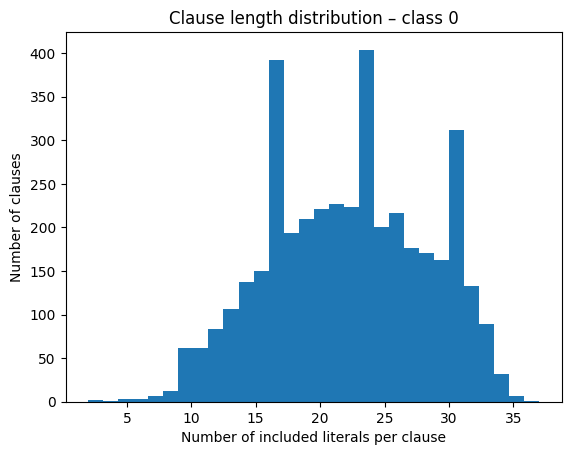

Class 0: median=22.0, mean=22.1, std=6.2


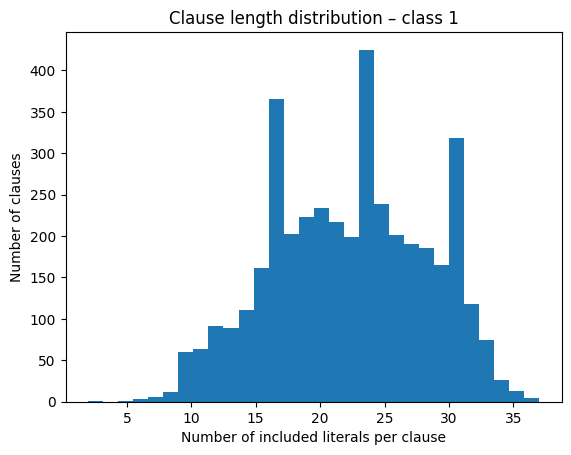

Class 1: median=22.0, mean=22.2, std=6.1


In [12]:
_ = plot_clause_length_distribution(tm)

Test Accuracy: 85.26%
2026-05-10 20:42:07,571 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-10 20:42:07,573 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-10 20:42:07,596 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x796c4ec956a0>


Saved to saved_confusion_matrices/breast_adaptive_mean.svg


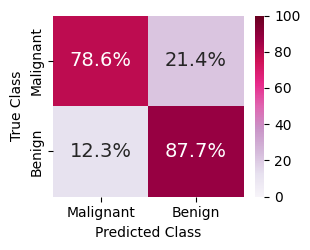

In [9]:
_, _ = plot_confusion_matrix_from_scores(config=config,  T= T_best, s= s_best, patch_size= patch_best, max_lit= maxlit_best, weighted= weighted_best, 
                                   Y_true=Y_test, specialist_name="BreastMNIST_Adaptive_Mean", dataset_name=CURRENT_DATASET, save_specialist_name=CURRENT_SPECIALIST, figsize=(3.2, 2.6), annot_fontsize=14, cmap = "PuRd") 

# Class 0 Local Examples

In [ ]:
# image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=0, random=True)
# print(f"Selected image index: {image_index}")
# print(f"True class: {Y_test[image_index]}")
# print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

Selected image index: 112
True class: 0
Predicted class: 0


0
2026-04-10 15:16:15,571 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 15:16:15,574 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
Visualizing sample 45  |  predicted class: 0
2026-04-10 15:16:15,603 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x723618e344a0>
Saved to saved_heatmaps/adaptive_mean/breast_adaptive_mean_lh_c0_s45_aggr.svg


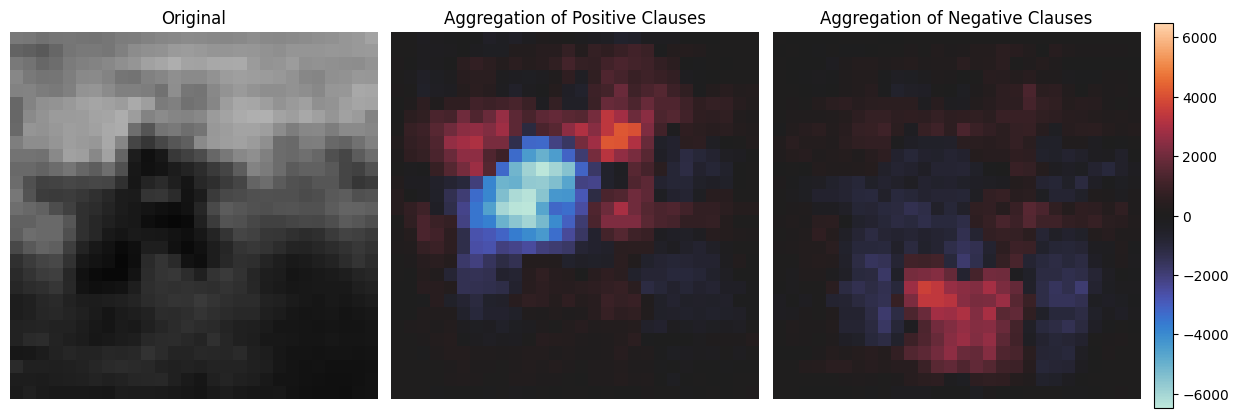

Visualizing sample 45  |  predicted class: 0
2026-04-10 15:16:18,939 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7235f6908890>
Saved to saved_heatmaps/adaptive_mean/breast_adaptive_mean_lh_c0_s45_chan.svg


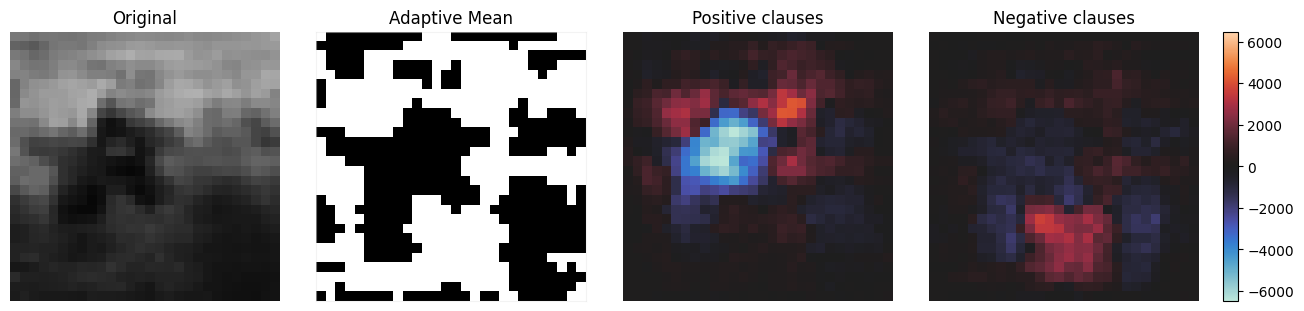

In [9]:
image_index =  45
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

0


Visualizing sample 23  |  predicted class: 0
2026-04-10 15:16:22,016 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7235fac4e0c0>
Saved to saved_heatmaps/adaptive_mean/breast_adaptive_mean_lh_c0_s23_aggr.svg


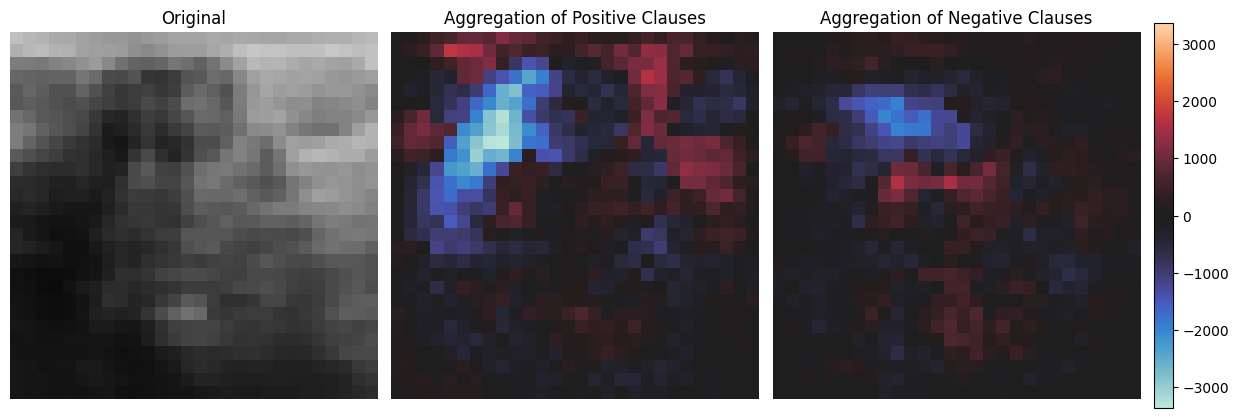

Visualizing sample 23  |  predicted class: 0
2026-04-10 15:16:25,125 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7235f471e2d0>
Saved to saved_heatmaps/adaptive_mean/breast_adaptive_mean_lh_c0_s23_chan.svg


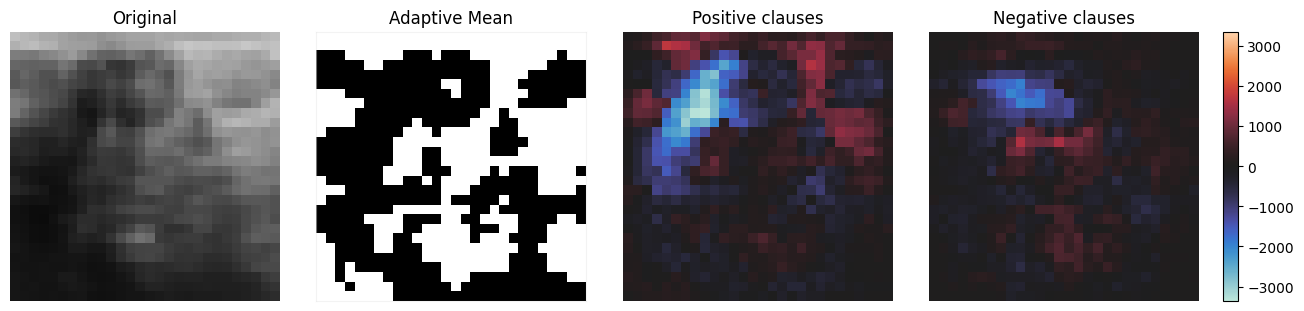

In [10]:
image_index =  23
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

0
Visualizing sample 85  |  predicted class: 0
2026-04-10 15:16:28,474 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7235f68e1a00>
Saved to saved_heatmaps/adaptive_mean/breast_adaptive_mean_lh_c0_s85_aggr.svg


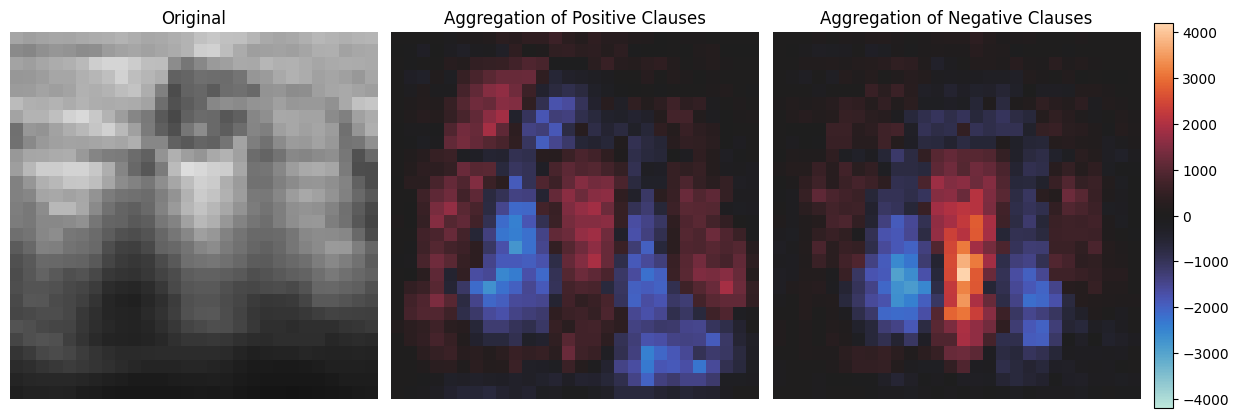

Visualizing sample 85  |  predicted class: 0
2026-04-10 15:16:31,902 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7235f44429c0>
Saved to saved_heatmaps/adaptive_mean/breast_adaptive_mean_lh_c0_s85_chan.svg


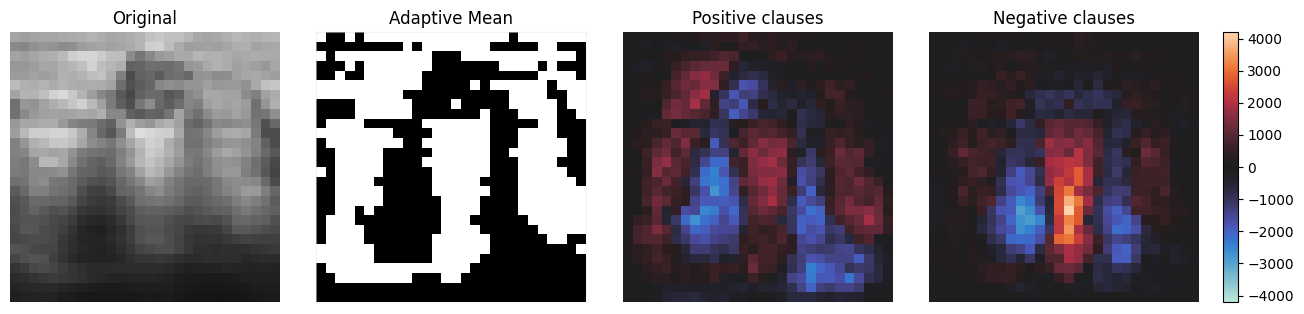

In [11]:
image_index =  85
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

0
Visualizing sample 135  |  predicted class: 0
2026-04-10 15:16:35,472 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7235f4323dd0>
Saved to saved_heatmaps/adaptive_mean/breast_adaptive_mean_lh_c0_s135_aggr.svg


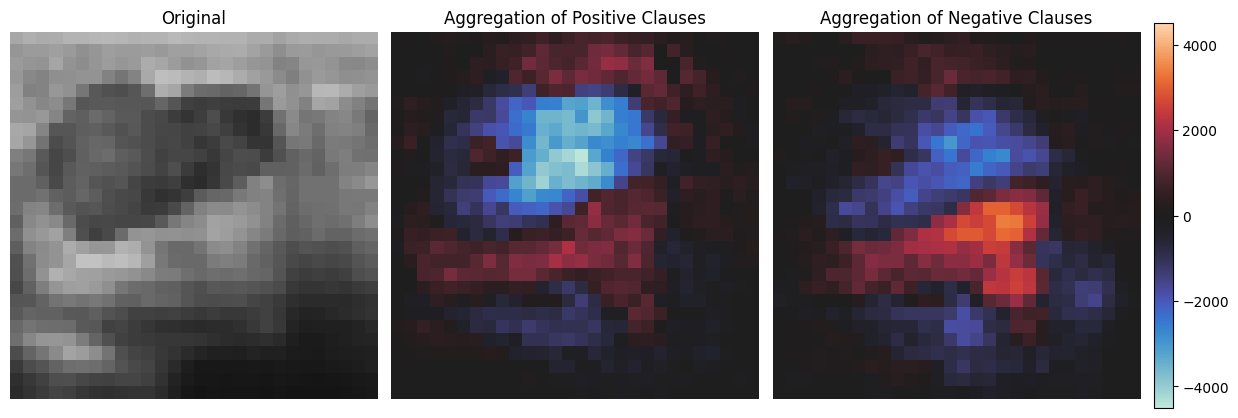

Visualizing sample 135  |  predicted class: 0
2026-04-10 15:16:38,818 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7235f42e1940>
Saved to saved_heatmaps/adaptive_mean/breast_adaptive_mean_lh_c0_s135_chan.svg


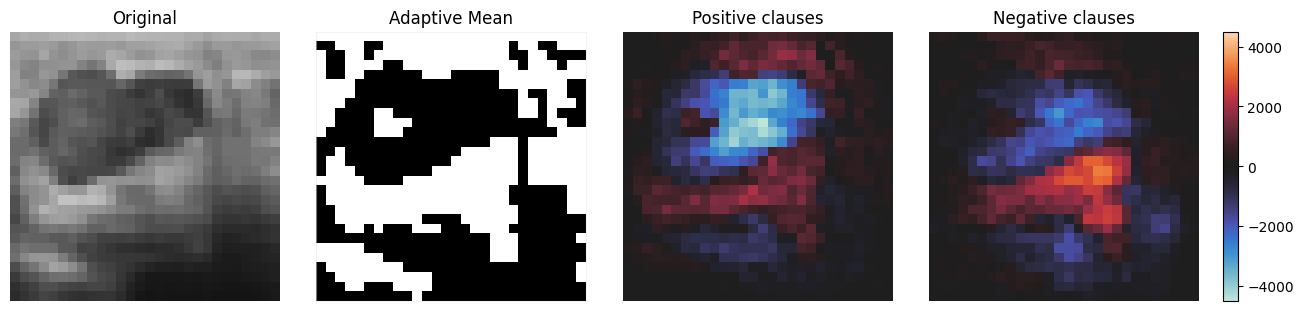

In [12]:
image_index =  135
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

# Class 1 Local Examples

In [13]:
# image_index = get_correct_sample_index(tm, X_test, Y_test, target_class=1, random=True)
# print(f"Selected image index: {image_index}")
# print(f"True class: {Y_test[image_index]}")
# print(f"Predicted class: {tm.predict(X_test[image_index:image_index+1])[0]}")

1
Visualizing sample 60  |  predicted class: 1
2026-04-10 15:16:41,893 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7235f41fb380>
Saved to saved_heatmaps/adaptive_mean/breast_adaptive_mean_lh_c1_s60_aggr.svg


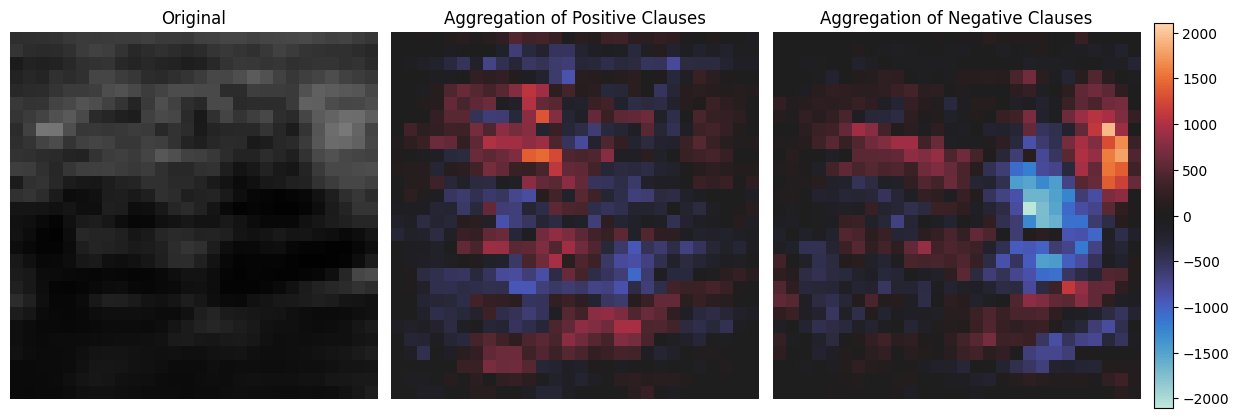

Visualizing sample 60  |  predicted class: 1
2026-04-10 15:16:45,190 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7235f4085790>
Saved to saved_heatmaps/adaptive_mean/breast_adaptive_mean_lh_c1_s60_chan.svg


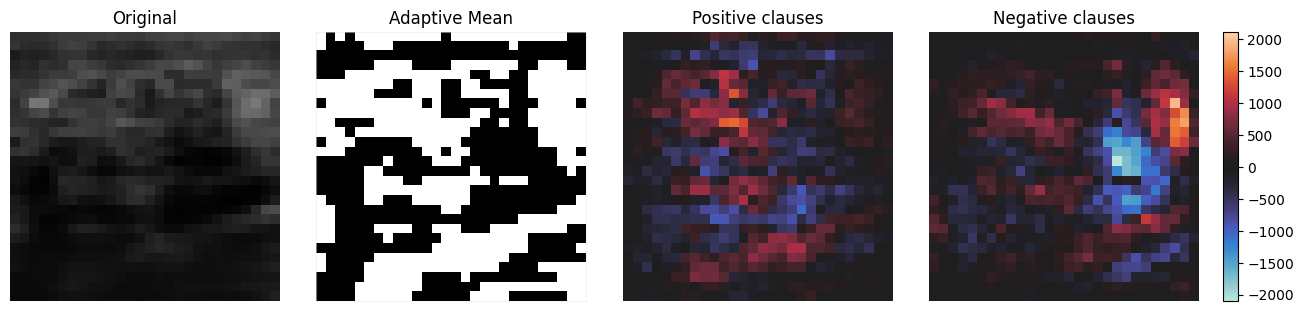

In [13]:
image_index =  60
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

1
Visualizing sample 154  |  predicted class: 1
2026-04-10 15:16:48,192 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7235f4160440>
Saved to saved_heatmaps/adaptive_mean/breast_adaptive_mean_lh_c1_s154_aggr.svg


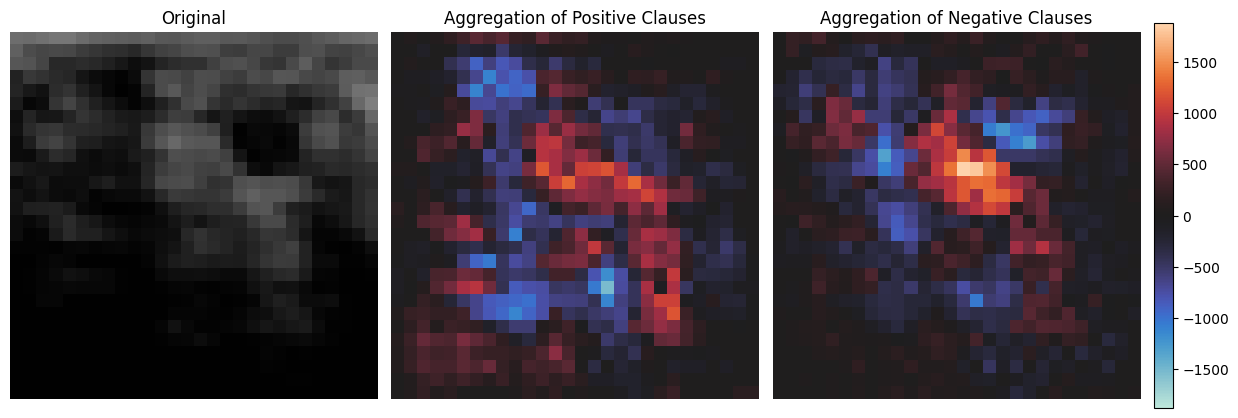

Visualizing sample 154  |  predicted class: 1
2026-04-10 15:16:51,200 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7235f409f530>
Saved to saved_heatmaps/adaptive_mean/breast_adaptive_mean_lh_c1_s154_chan.svg


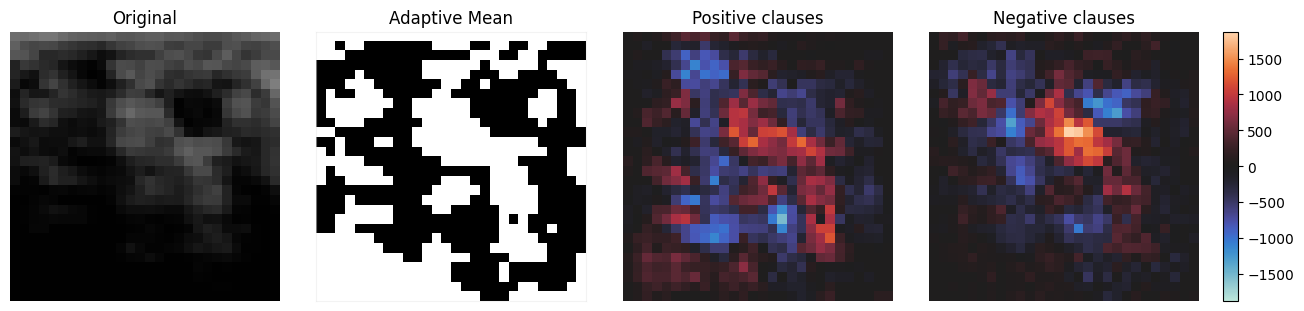

In [14]:
image_index =  154
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

1
Visualizing sample 121  |  predicted class: 1
2026-04-10 15:16:54,500 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7235f44424e0>
Saved to saved_heatmaps/adaptive_mean/breast_adaptive_mean_lh_c1_s121_aggr.svg


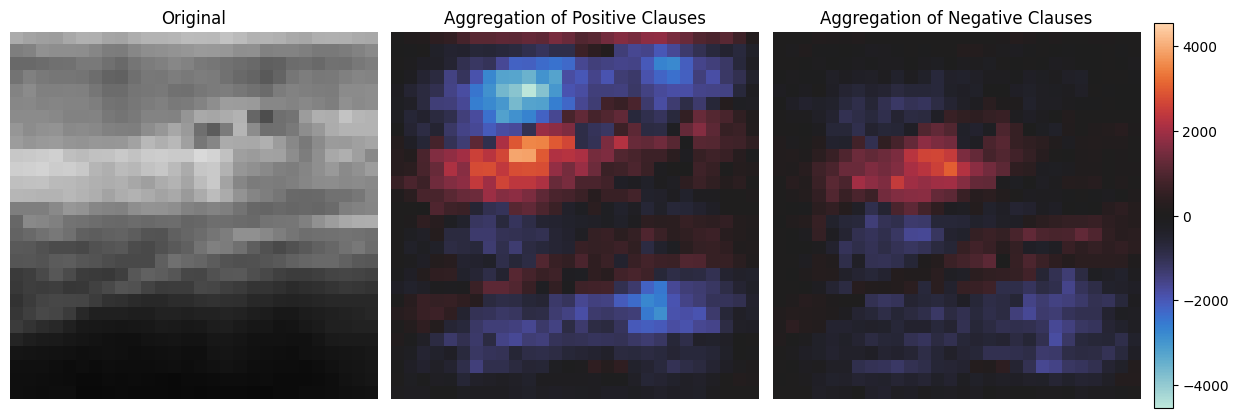

Visualizing sample 121  |  predicted class: 1
2026-04-10 15:16:58,480 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7235f4597e30>
Saved to saved_heatmaps/adaptive_mean/breast_adaptive_mean_lh_c1_s121_chan.svg


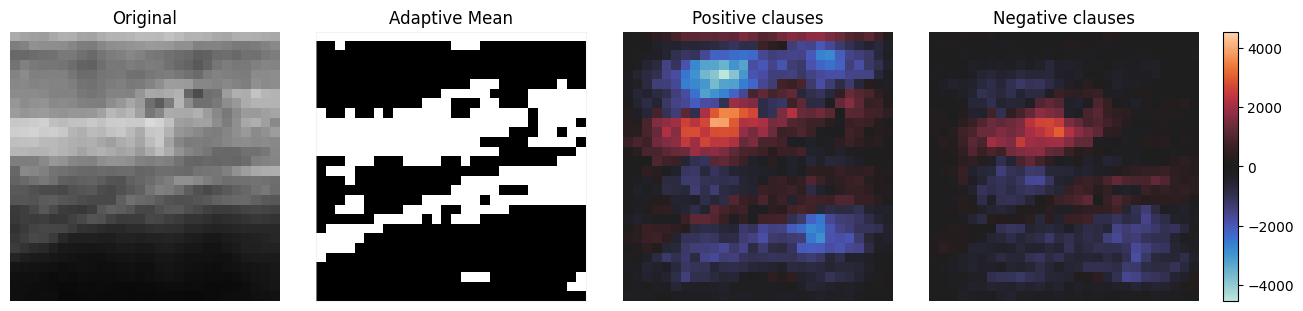

In [15]:
image_index =  121
target_class = Y_test[image_index]
print(Y_test[image_index])
save_path_aggregated=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.AGGREGATED_HEATMAP, image_index)
visualize_aggregated_heatmap(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, save_path=save_path_aggregated)

    
save_path_per_channel=build_save_path(os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),CURRENT_DATASET, CURRENT_SPECIALIST, config.LOCAL_HEATMAP, target_class, config.CHANNEL_HEATMAP, image_index)
visualize_per_channel_heatmaps(X_test, X_test_org, tm, image_index,
    resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), show_diff=False, channel_names=specialist_name, save_path=save_path_per_channel)

# Global Heatmap 0

In [17]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 0

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 18:47:11,432 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 18:47:11,436 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-10 18:47:11,461 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x76b6f2473350>
Saved to saved_heatmaps/adaptive_mean/breast_adaptive_mean_gh_c0.svg


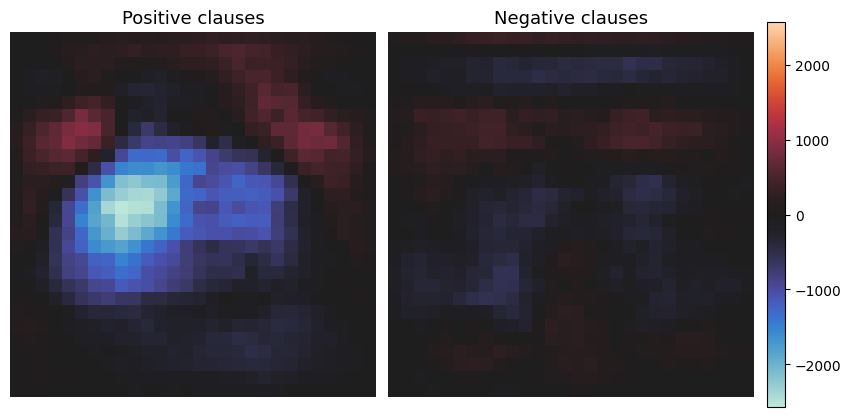

pos shape: (28, 28), min: -2568.30, max: 952.85
neg shape: (28, 28), min: -581.82, max: 519.88
saved_heatmaps/adaptive_mean/breast_adaptive_mean_gh_c0.svg


In [6]:
target_class = 0
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)

# Global Heatmap 1

In [19]:
# os.makedirs(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}", exist_ok=True)

# target_class = 1

# global_pos, global_neg, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm, target_class=target_class,
#     resolution= CURRENT_RESOLUTION, n_channels = config.CHANNELS, image_shape=(28, 28), max_samples=None, show_diff=False, show_sample=False)


    
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_pos.npy", global_pos)
# np.save(f"{config.SAVE_MAPS_DIR}/global/{CURRENT_SPECIALIST}/{CURRENT_SPECIALIST}_c{target_class}_neg.npy", global_neg)

2026-04-10 18:47:13,153 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x76b6ef398fe0>


Saved to saved_heatmaps/adaptive_mean/breast_adaptive_mean_gh_c1.svg


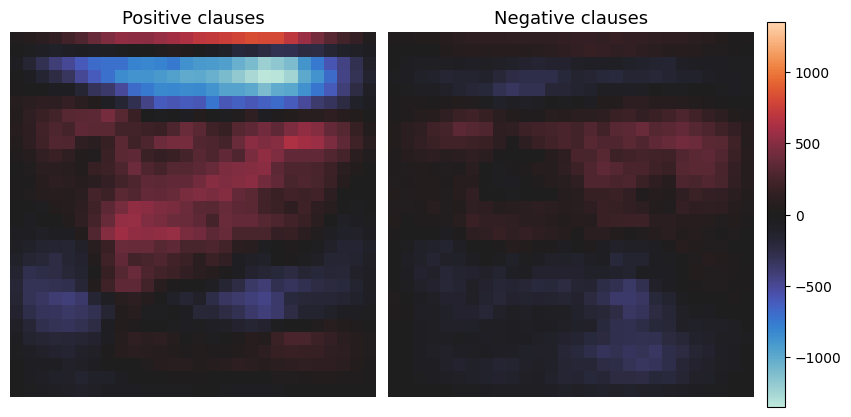

pos shape: (28, 28), min: -1349.09, max: 824.57
neg shape: (28, 28), min: -373.23, max: 426.33
saved_heatmaps/adaptive_mean/breast_adaptive_mean_gh_c1.svg


In [7]:
target_class = 1
save_path_global=build_save_path(base_dir=os.path.join(config.SAVE_DIR_HEATMAPS, CURRENT_SPECIALIST),dataset=CURRENT_DATASET, 
                                     specialist=CURRENT_SPECIALIST, heatmap_type=config.GLOBAL_HEATMAP, target_class=target_class)
load_raw_maps_and_plot_heatmap(config.SAVE_MAPS_DIR, CURRENT_SPECIALIST, target_class=target_class, save_path=save_path_global, title_pos=config.TITLE_GH_POS,
    title_neg=config.TITLE_GH_NEG)
print(save_path_global)